In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a project folder in your Drive
PROJECT_DIR = "/content/drive/MyDrive/pet_restoration_project"
os.makedirs(PROJECT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import json
import torch
import numpy as np
from torchvision.datasets import OxfordIIITPet

# Download data to Google Colab local storage (faster loading during training)
DATA_DIR = "/content/data"
dataset = OxfordIIITPet(root=DATA_DIR, split="trainval", download=True)
total_samples = len(dataset)

# Fix seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Shuffle indices
indices = torch.randperm(total_samples).tolist()

# 80/20 Train/Val Split
train_size = int(0.8 * total_samples)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

split_data = {
    "seed": SEED,
    "total_samples": total_samples,
    "train_indices": train_indices,
    "val_indices": val_indices
}

# Save to Google Drive so it survives Colab runtime disconnections
SPLIT_PATH = os.path.join(PROJECT_DIR, "split_indices.json")
with open(SPLIT_PATH, "w") as f:
    json.dump(split_data, f, indent=2)

print(f"Total samples: {total_samples}")
print(f"Train samples: {len(train_indices)} | Val samples: {len(val_indices)}")
print(f"Saved split indices to: {SPLIT_PATH}")

100%|██████████| 792M/792M [00:22<00:00, 34.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.4MB/s]


Total samples: 3680
Train samples: 2944 | Val samples: 736
Saved split indices to: /content/drive/MyDrive/pet_restoration_project/split_indices.json


In [4]:
import os
import json
import torch
from torch.utils.data import Subset, DataLoader
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.v2 as transforms

PROJECT_DIR = "/content/drive/MyDrive/pet_restoration_project"
SPLIT_PATH = os.path.join(PROJECT_DIR, "split_indices.json")

# Define the transform FIRST
base_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((128, 128)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
])

# Pass it to the constructor (setting .transform afterwards is ignored)
full_dataset = OxfordIIITPet(root="/content/data", split="trainval",
                             download=True, transform=base_transform)

with open(SPLIT_PATH, "r") as f:
    splits = json.load(f)

train_dataset = Subset(full_dataset, splits["train_indices"])
val_dataset = Subset(full_dataset, splits["val_indices"])

print(f"Loaded Train set: {len(train_dataset)} samples")
print(f"Loaded Val set: {len(val_dataset)} samples")
print(type(val_dataset[0][0]), val_dataset[0][0].shape)   # must be a tensor, [3,128,128]

Loaded Train set: 2944 samples
Loaded Val set: 736 samples
<class 'torchvision.tv_tensors._image.Image'> torch.Size([3, 128, 128])


In [5]:
import math
import random
import torch
import torch.nn.functional as F

def apply_salt_and_pepper(img_tensor, p=None, seed=None):
    corrupted = img_tensor.clone()
    if p is None:
        p = random.uniform(0.02, 0.15)
    g = torch.Generator().manual_seed(seed) if seed is not None else None

    _, H, W = corrupted.shape
    n = int(p * H * W)
    ys = torch.randint(0, H, (n,), generator=g)
    xs = torch.randint(0, W, (n,), generator=g)
    vals = (torch.rand(n, generator=g) < 0.5).float()
    for c in range(3):
        corrupted[c, ys, xs] = vals
    return corrupted, {"p": p, "seed": seed}


def sample_occlusion_coords(rng, num_rects, target_coverage, H=128, W=128,
                            tol=0.02, max_tries=50):
    """rng is any object with .uniform/.randint (random module or random.Random).
    Retries until the UNION area (overlaps counted once) is within tol of target."""
    best, best_err = None, 1e9
    for _ in range(max_tries):
        area_per = target_coverage * H * W / num_rects
        mask = torch.zeros(H, W, dtype=torch.bool)
        coords = []
        for _ in range(num_rects):
            ar = rng.uniform(0.5, 2.0)
            h = max(1, min(H, int(round(math.sqrt(area_per / ar)))))
            w = max(1, min(W, int(round(area_per / h))))
            top, left = rng.randint(0, H - h), rng.randint(0, W - w)
            mask[top:top+h, left:left+w] = True
            coords.append([top, left, h, w])
        cov = mask.float().mean().item()
        if abs(cov - target_coverage) < best_err:
            best, best_err = (coords, cov), abs(cov - target_coverage)
        if best_err <= tol:
            break
    return best


def apply_occlusion(img_tensor, num_rects=None, target_coverage=None, rect_coords=None):
    corrupted = img_tensor.clone()
    if rect_coords is None:                      # training path
        num_rects = num_rects or random.randint(1, 3)
        target_coverage = target_coverage or random.uniform(0.10, 0.35)
        rect_coords, _ = sample_occlusion_coords(random, num_rects, target_coverage)
    for top, left, h, w in rect_coords:          # replay path
        corrupted[:, top:top+h, left:left+w] = 0.0
    return corrupted, {"num_rects": len(rect_coords), "rect_coords": rect_coords}


def apply_gaussian_blur(img_tensor, kernel_size=None, sigma=None):
    if kernel_size is None:
        kernel_size = random.choice([3, 5, 7])
    if sigma is None:
        sigma = random.uniform(0.5, 2.5)

    radius = kernel_size // 2
    x = torch.arange(-radius, radius + 1, dtype=torch.float32)
    kernel_1d = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()

    kernel_2d = torch.outer(kernel_1d, kernel_1d)
    kernel_2d = kernel_2d.view(1, 1, kernel_size, kernel_size).repeat(3, 1, 1, 1)

    img_batch = img_tensor.unsqueeze(0)

    # Reflect padding avoids darkened borders; no zero padding in the conv
    img_batch = F.pad(img_batch, [radius] * 4, mode="reflect")
    blurred_batch = F.conv2d(img_batch, kernel_2d, padding=0, groups=3)

    return blurred_batch.squeeze(0), {"kernel_size": kernel_size, "sigma": sigma}



In [6]:
import torchvision.transforms.v2.functional as TF
from torch.utils.data import Dataset

CORRUPTION_TYPES = ["clean", "salt", "blur", "occlusion"]

class CorruptedPetTrainDataset(Dataset):
    def __init__(self, base_subset):
        self.base_subset = base_subset

    def __len__(self):
        return len(self.base_subset)

    def __getitem__(self, idx):
        clean_img, _ = self.base_subset[idx]

        # Defensive: ensure tensor even if upstream transform wasn't applied
        if not torch.is_tensor(clean_img):
            clean_img = TF.to_image(clean_img.convert("RGB"))
            clean_img = TF.resize(clean_img, [128, 128])
            clean_img = TF.to_dtype(clean_img, torch.float32, scale=True)

        label = random.randint(0, 3)
        condition = CORRUPTION_TYPES[label]

        if condition == "clean":
            corrupted_img = clean_img.clone()
        elif condition == "salt":
            corrupted_img, _ = apply_salt_and_pepper(clean_img)
        elif condition == "blur":
            corrupted_img, _ = apply_gaussian_blur(clean_img)
        else:
            corrupted_img, _ = apply_occlusion(clean_img)

        return corrupted_img, clean_img, label

In [7]:
train_corrupted_dataset = CorruptedPetTrainDataset(train_dataset)
train_loader = DataLoader(train_corrupted_dataset, batch_size=32, shuffle=True)

print(f"Train corrupted dataset ready: {len(train_corrupted_dataset)} samples")

Train corrupted dataset ready: 2944 samples


In [8]:
def make_entry(i, cond, rng, seed, severity=None, sev_params=None):
    e = {"index": i, "label": CORRUPTION_TYPES.index(cond), "condition": cond,
         "severity": severity, "seed": seed}
    if cond == "salt":
        e["p"] = sev_params if sev_params is not None else rng.uniform(0.02, 0.15)
    elif cond == "blur":
        if sev_params is not None:
            e["kernel_size"], e["sigma"] = sev_params
        else:
            e["kernel_size"], e["sigma"] = rng.choice([3, 5, 7]), rng.uniform(0.5, 2.5)
    elif cond == "occlusion":
        if sev_params is not None:
            n, cov = sev_params
        else:
            n, cov = rng.randint(1, 3), rng.uniform(0.10, 0.35)
        coords, actual = sample_occlusion_coords(rng, n, cov)
        e.update(num_rects=n, target_coverage=cov, actual_coverage=actual, rect_coords=coords)
    return e


def generate_val_manifest(n_images, base_seed):
    manifest = []
    for i in range(n_images):
        seed = base_seed * 10_000_000 + i
        rng = random.Random(seed)
        cond = CORRUPTION_TYPES[rng.randint(0, 3)]
        manifest.append(make_entry(i, cond, rng, seed, severity="random"))
    return manifest


TEST_SEVERITIES = {
    "salt":      [0.03, 0.08, 0.15],
    "blur":      [(3, 0.7), (5, 1.5), (7, 2.5)],
    "occlusion": [(1, 0.10), (2, 0.20), (3, 0.35)],
}
SEV_NAMES = ["low", "medium", "high"]

def generate_test_manifest(n_images, base_seed):
    manifest = []
    for i in range(n_images):
        k = 0
        seed = base_seed * 10_000_000 + i * 10 + k
        manifest.append(make_entry(i, "clean", random.Random(seed), seed, severity="none"))
        for cond, params in TEST_SEVERITIES.items():
            for s, sp in enumerate(params):
                k += 1
                seed = base_seed * 10_000_000 + i * 10 + k
                manifest.append(make_entry(i, cond, random.Random(seed), seed,
                                           severity=SEV_NAMES[s], sev_params=sp))
    return manifest


# --- val: delete the old file, regenerate ---
VAL_MANIFEST_PATH = os.path.join(PROJECT_DIR, "val_manifest.json")
val_manifest = generate_val_manifest(len(val_dataset), SEED)
json.dump(val_manifest, open(VAL_MANIFEST_PATH, "w"))

# --- test ---
test_base = OxfordIIITPet(root="/content/data", split="test", download=True,
                          transform=base_transform)
TEST_MANIFEST_PATH = os.path.join(PROJECT_DIR, "test_manifest.json")
test_manifest = generate_test_manifest(len(test_base), SEED)
json.dump(test_manifest, open(TEST_MANIFEST_PATH, "w"))
print(len(test_base), "images ->", len(test_manifest), "entries")   # 3669 -> 36690

3669 images -> 36690 entries


In [9]:
class ManifestPetDataset(Dataset):
    def __init__(self, base_dataset, manifest):
        self.base, self.manifest = base_dataset, manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        e = self.manifest[idx]
        clean, _ = self.base[e["index"]]
        c = e["condition"]
        if c == "clean":
            x = clean.clone()
        elif c == "salt":
            x, _ = apply_salt_and_pepper(clean, p=e["p"], seed=e["seed"])
        elif c == "blur":
            x, _ = apply_gaussian_blur(clean, e["kernel_size"], e["sigma"])
        else:
            x, _ = apply_occlusion(clean, rect_coords=e["rect_coords"])
        return x, clean, e["label"]

val_corrupted_dataset  = ManifestPetDataset(val_dataset, val_manifest)
test_corrupted_dataset = ManifestPetDataset(test_base, test_manifest)
val_loader  = DataLoader(val_corrupted_dataset,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_corrupted_dataset, batch_size=32, shuffle=False)

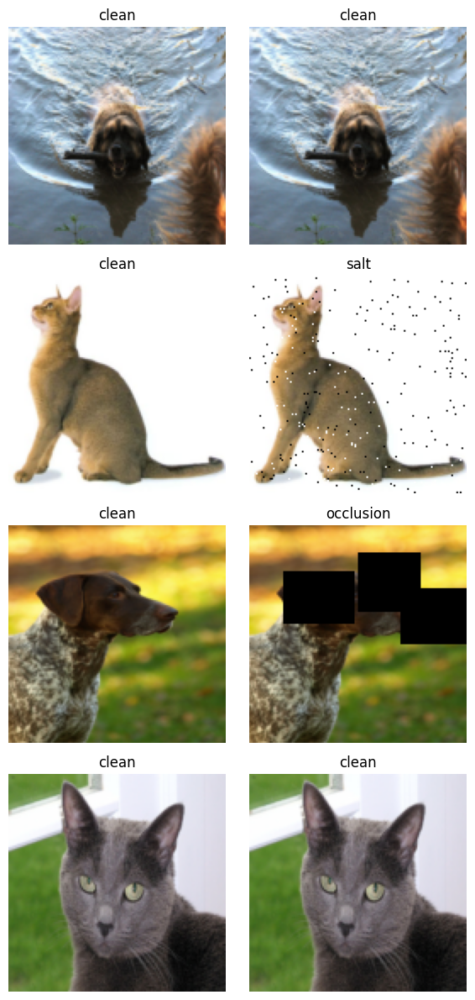

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(6, 12))
for i in range(4):
    corrupted, clean, label = train_corrupted_dataset[i]
    axes[i, 0].imshow(clean.permute(1, 2, 0))
    axes[i, 0].set_title("clean")
    axes[i, 1].imshow(corrupted.permute(1, 2, 0))
    axes[i, 1].set_title(CORRUPTION_TYPES[label])
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# 1. Determinism: loading twice must give identical tensors
for ds in (val_corrupted_dataset, test_corrupted_dataset):
    for idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        a, _, _ = ds[idx]; b, _, _ = ds[idx]
        assert torch.equal(a, b), f"non-deterministic at {idx}"

# 2. Occlusion coverage should be close to 10/20/35%
for sev in SEV_NAMES:
    covs = [e["actual_coverage"] for e in test_manifest
            if e["condition"] == "occlusion" and e["severity"] == sev]
    print(sev, round(sum(covs) / len(covs), 3))

# 3. Visualise ~20 test images: clean | one row per condition × severity

low 0.1
medium 0.197
high 0.343


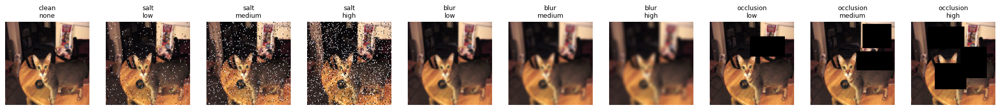

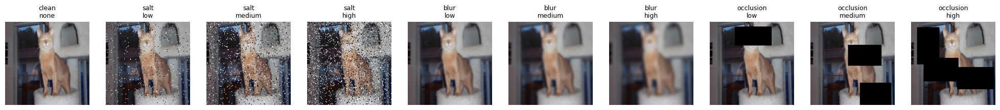

In [ ]:
import matplotlib.pyplot as plt

def show_test_image(img_idx):
    entries = [(j, e) for j, e in enumerate(test_manifest) if e["index"] == img_idx]
    fig, axes = plt.subplots(1, 10, figsize=(25, 3))
    for ax, (j, e) in zip(axes, entries):
        x, _, _ = test_corrupted_dataset[j]
        ax.imshow(x.permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"{e['condition']}\n{e['severity']}", fontsize=9)
        ax.axis("off")
    plt.show()

for i in [0, 1]:
    show_test_image(i)

In [22]:
import torch, torch.nn as nn, torch.nn.functional as F

class UniversalDAE(nn.Module):
    """128->64->32->16->8 encoder, linear latent bottleneck, mirrored decoder. No skips."""
    def __init__(self, base_ch=64, latent_dim=256, dropout=0.1):
        super().__init__()
        c = base_ch
        chs = [3, c, c*2, c*4, c*8]
        enc = []
        for i in range(4):
            enc += [nn.Conv2d(chs[i], chs[i+1], 4, 2, 1),
                    nn.BatchNorm2d(chs[i+1]), nn.LeakyReLU(0.2, True)]
        self.encoder = nn.Sequential(*enc)               # -> [c*8, 8, 8]
        self.flat = c*8*8*8
        self.to_latent = nn.Sequential(nn.Flatten(), nn.Dropout(dropout),
                                       nn.Linear(self.flat, latent_dim))
        self.from_latent = nn.Sequential(nn.Linear(latent_dim, self.flat), nn.LeakyReLU(0.2, True))
        dec = []
        for i in range(4, 0, -1):
            dec += [nn.Upsample(scale_factor=2, mode="nearest"),
                    nn.Conv2d(chs[i], chs[i-1] if i > 1 else c, 3, 1, 1),
                    nn.BatchNorm2d(chs[i-1] if i > 1 else c), nn.ReLU(True)]
        self.decoder = nn.Sequential(*dec)
        self.out = nn.Sequential(nn.Conv2d(c, 3, 3, 1, 1), nn.Sigmoid())
        self.c8 = c*8

    def forward(self, x):
        z = self.to_latent(self.encoder(x))
        h = self.from_latent(z).view(-1, self.c8, 8, 8)
        return self.out(self.decoder(h))

# --- SSIM (gaussian window 11, sigma 1.5) ---
def _gauss_win(size=11, sigma=1.5, ch=3, device="cpu"):
    g = torch.exp(-0.5 * ((torch.arange(size) - size//2) / sigma) ** 2)
    g = (g / g.sum()).to(device)
    w = torch.outer(g, g)
    return w.expand(ch, 1, size, size).contiguous()

def ssim(x, y, C1=0.01**2, C2=0.03**2):
    w = _gauss_win(device=x.device)
    f = lambda t: F.conv2d(t, w, padding=5, groups=3)
    mx, my = f(x), f(y)
    sxx, syy, sxy = f(x*x) - mx**2, f(y*y) - my**2, f(x*y) - mx*my
    s = ((2*mx*my + C1) * (2*sxy + C2)) / ((mx**2 + my**2 + C1) * (sxx + syy + C2))
    return s.mean()

def restoration_loss(pred, target, alpha):
    return alpha * F.l1_loss(pred, target) + (1 - alpha) * (1 - ssim(pred, target))

def psnr(pred, target):
    mse = F.mse_loss(pred, target, reduction="none").mean(dim=(1,2,3))
    return (10 * torch.log10(1.0 / mse.clamp_min(1e-10))).mean()

In [ ]:
import wandb, optuna
device = "cuda"

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    l1 = ss = ps = n = 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        p = model(x); b = x.size(0)
        l1 += F.l1_loss(p, y).item()*b; ss += ssim(p, y).item()*b; ps += psnr(p, y).item()*b; n += b
    return {"val_l1": l1/n, "val_ssim": ss/n, "val_psnr": ps/n,
            "val_score": l1/n + (1 - ss/n)}          # objective: lower is better

def train_model(cfg, epochs, trial=None, log=True):
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    tl = DataLoader(train_corrupted_dataset, batch_size=cfg["batch_size"], shuffle=True,
                    num_workers=2, drop_last=True, persistent_workers=True)
    vl = DataLoader(val_corrupted_dataset, batch_size=64, shuffle=False, num_workers=2)
    best, best_state = 1e9, None
    for ep in range(epochs):
        model.train(); run = 0
        for x, y, _ in tl:
            x, y = x.to(device), y.to(device)
            loss = restoration_loss(model(x), y, cfg["alpha"])
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
        sched.step()
        m = evaluate(model, vl); m["train_loss"] = run/len(tl); m["epoch"] = ep
        if log: wandb.log(m)
        if m["val_score"] < best:
            best = m["val_score"]; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if trial:
            trial.report(m["val_score"], ep)
            if trial.should_prune(): raise optuna.TrialPruned()
    return model, best, best_state

In [ ]:
def objective(trial):
    cfg = {
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "latent_dim": trial.suggest_categorical("latent_dim", [128, 256, 512, 1024]),
        "base_ch": trial.suggest_categorical("base_ch", [32, 48, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.3),
        "alpha": trial.suggest_float("alpha", 0.5, 0.95),
    }
    wandb.init(project="genai-ass1", group="task1-optuna", name=f"t1-trial{trial.number}",
               config=cfg, reinit=True)
    try:
        _, best, _ = train_model(cfg, epochs=8, trial=trial)
        wandb.log({"best_val_score": best})
        return best
    finally:
        wandb.finish()

study = optuna.create_study(
    direction="minimize", study_name="task1_dae",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    storage=f"sqlite:///{PROJECT_DIR}/task1_optuna.db", load_if_exists=True)


study.optimize(objective, n_trials=25)
print(study.best_trial.number, study.best_value, study.best_params)

[I 2026-10-02 18:02:53,496] Using an existing study with `study_name='task1_dae'` instead of creating a new one.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: taha05 (taha05-fast) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


best_val_score,▁
epoch,▁▂▃▄▅▆▇█
train_loss,█▅▄▃▃▂▁▁
val_l1,█▅▄▄▃▂▁▁
val_psnr,▁▄▅▅▆▇██
val_score,█▅▄▄▂▂▁▁
val_ssim,▁▃▅▆▇▇██
best_val_score,0.58719
epoch,7
train_loss,0.13819
val_l1,0.08505


[I 2026-10-02 18:05:49,100] Trial 7 finished with value: 0.5871853808993879 and parameters: {'lr': 0.0003574712922600243, 'batch_size': 16, 'latent_dim': 1024, 'base_ch': 48, 'dropout': 0.29097295564859826, 'alpha': 0.8745991883601898}. Best is trial 3 with value: 0.5754256902829461.


epoch,▁▃▅▆█
train_loss,█▄▃▂▁
val_l1,█▄▃▁▁
val_psnr,▁▄▆▇█
val_score,█▅▃▂▁
val_ssim,▁▄▆▇█
epoch,4
train_loss,0.15692
val_l1,0.09856
val_psnr,17.86926
val_score,0.61708


[I 2026-10-02 18:07:36,886] Trial 8 pruned. 


...

[I 2026-10-02 18:44:44,638] Trial 32 pruned. 


best_val_score,▁
epoch,▁▂▃▄▅▆▇█
train_loss,█▅▃▃▂▂▁▁
val_l1,█▇▄▃▃▂▁▁
val_psnr,▁▃▅▆▇▇▇█
val_score,█▆▄▃▃▂▁▁
val_ssim,▁▃▅▆▆▇██
best_val_score,0.56814
epoch,7
train_loss,0.13141
val_l1,0.08022


[I 2026-10-02 18:47:33,729] Trial 33 finished with value: 0.5681372375591941 and parameters: {'lr': 0.00010787582551682712, 'batch_size': 32, 'latent_dim': 1024, 'base_ch': 64, 'dropout': 0.03322195063392052, 'alpha': 0.8588074887856978}. Best is trial 22 with value: 0.5640095232621483.


wandb: ERROR Control-C detected -- Run data was not synced
wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.
[W 2026-10-02 18:48:13,609] Trial 34 failed with parameters: {'lr': 0.00013772389072097942, 'batch_size': 32, 'latent_dim': 1024, 'base_ch': 48, 'dropout': 0.18101436672292093, 'alpha': 0.9053423901902001} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/tmp/ipykernel_11417/2966396134.py", line 13, in objective
    _, best, _ = train_model(cfg, epochs=8, trial=trial)
                 ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_11417/2779040529.py", line 28, in train_model
    opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
                                                         ~~~~~~~~~^^
KeyboardInterrupt

During handling of the above exception, another exception occu

KeyboardInterrupt: 

22 0.5640095232621483
state
PRUNED      19
COMPLETE    12
FAIL         4
Name: count, dtype: int64
22 0.5640095232621483 {'lr': 0.0001609852727057712, 'batch_size': 32, 'latent_dim': 1024, 'base_ch': 48, 'dropout': 0.06928354535372097, 'alpha': 0.7710590441479857}


/tmp/ipykernel_3865/3207486913.py:19: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); plt.tight_layout()


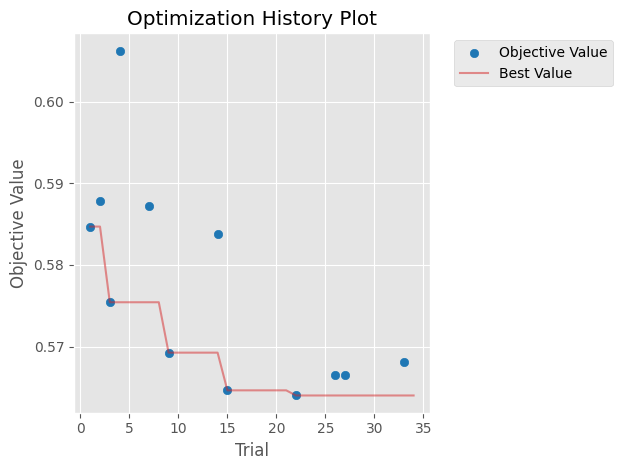

/tmp/ipykernel_3865/3207486913.py:19: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); plt.tight_layout()


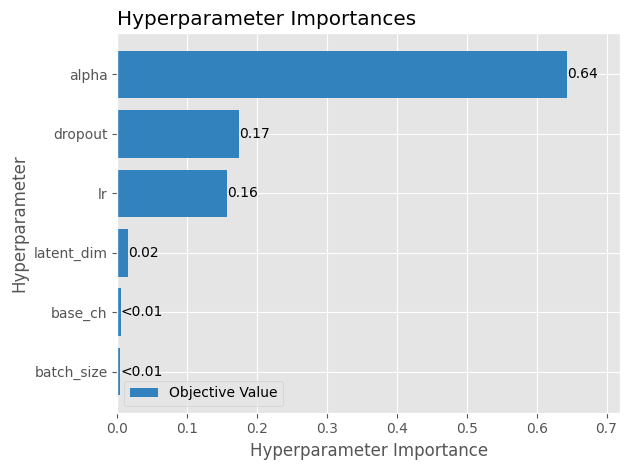

/tmp/ipykernel_3865/3207486913.py:19: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); plt.tight_layout()


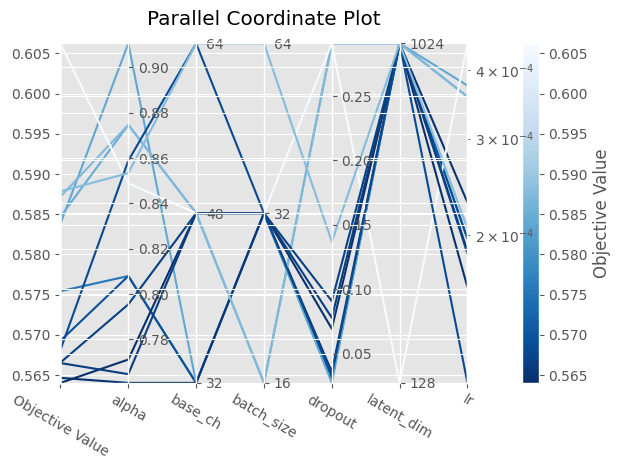

In [ ]:
import optuna
PROJECT_DIR = "/content/drive/MyDrive/pet_restoration_project"
study = optuna.load_study(
    study_name="task1_dae",
    storage=f"sqlite:///{PROJECT_DIR}/task1_optuna.db")
print(study.best_trial.number, study.best_value)

import pandas as pd, matplotlib.pyplot as plt
from optuna.visualization import matplotlib as optv

df = study.trials_dataframe()
df.to_csv(f"{PROJECT_DIR}/task1_optuna_trials.csv", index=False)
print(df["state"].value_counts())
print(study.best_trial.number, study.best_value, study.best_params)

for name, fn in [("history", optv.plot_optimization_history),
                 ("importance", optv.plot_param_importances),
                 ("parallel", optv.plot_parallel_coordinate)]:
    fn(study); plt.tight_layout()
    plt.savefig(f"{PROJECT_DIR}/task1_optuna_{name}.png", dpi=200); plt.show()

In [ ]:
import wandb
best_cfg = study.best_params
EPOCHS = 60
wandb.init(project="genai-ass1", group="task1-final", name="t1-final",
           config={**best_cfg, "epochs": EPOCHS}, reinit=True)
model, best, best_state = train_model(best_cfg, epochs=EPOCHS)
wandb.finish()

torch.save({"cfg": best_cfg, "state_dict": best_state},
           f"{PROJECT_DIR}/task1_best.pth")
print("best val_score:", best)

In [23]:
class SpatialDAE(UniversalDAE):
    def __init__(self, base_ch=48, latent_ch=64, dropout=0.07):
        super().__init__(base_ch, 128, dropout)
        c8 = base_ch * 8
        self.to_latent = nn.Sequential(nn.Conv2d(c8, latent_ch, 1), nn.Dropout2d(dropout))
        self.from_latent = nn.Sequential(nn.Conv2d(latent_ch, c8, 1), nn.LeakyReLU(0.2, True))
    def forward(self, x):
        h = self.from_latent(self.to_latent(self.encoder(x)))
        return self.out(self.decoder(h))

def build_model(cfg):
    if cfg.get("arch") == "spatial":
        return SpatialDAE(cfg["base_ch"], cfg["latent_ch"], cfg["dropout"])
    return UniversalDAE(cfg["base_ch"], cfg["latent_dim"], cfg["dropout"])

In [ ]:
import pandas as pd

ckpt = torch.load(f"{PROJECT_DIR}/task1_spatial_best.pth", map_location=device)
cfg = ckpt["cfg"]
model = build_model(cfg).to(device)
model.load_state_dict(ckpt["state_dict"]); model.eval()

def ssim_per_image(x, y, C1=0.01**2, C2=0.03**2):
    w = _gauss_win(device=x.device)
    f = lambda t: F.conv2d(t, w, padding=5, groups=3)
    mx, my = f(x), f(y)
    sxx, syy, sxy = f(x*x) - mx**2, f(y*y) - my**2, f(x*y) - mx*my
    s = ((2*mx*my + C1) * (2*sxy + C2)) / ((mx**2 + my**2 + C1) * (sxx + syy + C2))
    return s.mean(dim=(1, 2, 3))

def per_image(p, y):
    l1 = (p - y).abs().mean(dim=(1, 2, 3))
    mse = ((p - y) ** 2).mean(dim=(1, 2, 3))
    ps = 10 * torch.log10(1.0 / mse.clamp_min(1e-10))
    return l1, ps, ssim_per_image(p, y)

test_loader = DataLoader(test_corrupted_dataset, batch_size=128,
                         shuffle=False, num_workers=2)
rows, i = [], 0
with torch.no_grad():
    for x, y, _ in test_loader:
        x, y = x.to(device), y.to(device)
        p = model(x)
        l1, ps, ss = per_image(p, y)
        l1i, psi, ssi = per_image(x, y)
        for k in range(x.size(0)):
            e = test_manifest[i]; i += 1
            rows.append(dict(condition=e["condition"], severity=e["severity"],
                             l1=l1[k].item(), psnr=ps[k].item(), ssim=ss[k].item(),
                             l1_in=l1i[k].item(), psnr_in=psi[k].item(), ssim_in=ssi[k].item()))

df = pd.DataFrame(rows)
df.loc[df.condition == "clean", ["psnr_in"]] = float("nan")   # identical to target
cond_order = {"clean": 0, "salt": 1, "blur": 2, "occlusion": 3}
sev_order = {"none": 0, "low": 1, "medium": 2, "high": 3}

tbl = df.groupby(["condition", "severity"]).mean(numeric_only=True).round(4).reset_index()
tbl["c"] = tbl["condition"].map(cond_order)
tbl["s"] = tbl["severity"].map(sev_order)
tbl = tbl.sort_values(["c", "s"]).drop(columns=["c", "s"]).set_index(["condition", "severity"])

print(tbl)
tbl.to_csv(f"{PROJECT_DIR}/task1_test_results.csv")
df.to_csv(f"{PROJECT_DIR}/task1_test_per_image.csv", index=False)

KeyboardInterrupt: 

In [ ]:
cond_order = {"clean": 0, "salt": 1, "blur": 2, "occlusion": 3}
sev_order = {"none": 0, "low": 1, "medium": 2, "high": 3}

tbl = df.groupby(["condition", "severity"]).mean(numeric_only=True).round(4).reset_index()
tbl["c"] = tbl["condition"].map(cond_order)
tbl["s"] = tbl["severity"].map(sev_order)
tbl = tbl.sort_values(["c", "s"]).drop(columns=["c", "s"]).set_index(["condition", "severity"])

print(tbl)
tbl.to_csv(f"{PROJECT_DIR}/task1_spatial_test_results.csv")
df.to_csv(f"{PROJECT_DIR}/task1_spatial_test_per_image.csv", index=False)

                        l1     psnr    ssim   l1_in  psnr_in  ssim_in
condition severity                                                   
clean     none      0.0382  25.3385  0.7777  0.0000      NaN   1.0000
salt      low       0.0381  25.3572  0.7755  0.0148  20.2154   0.6168
          medium    0.0384  25.2980  0.7699  0.0384  16.0665   0.3663
          high      0.0395  25.0714  0.7590  0.0696  13.4827   0.2372
blur      low       0.0376  25.5069  0.7788  0.0129  34.0744   0.9613
          medium    0.0375  25.5634  0.7716  0.0260  28.0647   0.8548
          high      0.0402  24.9297  0.7407  0.0362  25.3187   0.7545
occlusion low       0.0451  23.1618  0.7405  0.0440  16.7775   0.8792
          medium    0.0525  21.6271  0.7037  0.0879  13.3798   0.7639
          high      0.0651  19.7796  0.6468  0.1529  10.8394   0.5998


In [ ]:
cfg_sp = {**best_cfg, "arch": "spatial", "latent_ch": 64}
wandb.init(project="genai-ass1", group="task1-bottleneck-ablation",
           name="spatial-64ch", config=cfg_sp, reinit=True)
_, best_sp, _ = train_model(cfg_sp, epochs=8)
wandb.finish()
print("spatial:", best_sp, "| flat baseline at 8 epochs: 0.564")

epoch,▁▂▃▄▅▆▇█
train_loss,█▄▃▂▂▁▁▁
val_l1,█▄▃▅▂▂▁▁
val_psnr,▁▄▅▄▇▇██
val_score,█▄▃▃▂▁▁▁
val_ssim,▁▅▆▆▇███
epoch,7
train_loss,0.12342
val_l1,0.05306
val_psnr,22.54595
val_score,0.39397


spatial: 0.3939735133038915 | flat baseline at 8 epochs: 0.564


In [ ]:
def objective_sp(trial):
    cfg = {
        "arch": "spatial",
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "latent_ch": trial.suggest_categorical("latent_ch", [16, 32, 64, 128]),
        "base_ch": trial.suggest_categorical("base_ch", [32, 48, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.3),
        "alpha": trial.suggest_float("alpha", 0.5, 0.95),
    }
    wandb.init(project="genai-ass1", group="task1-optuna-spatial",
               name=f"t1sp-trial{trial.number}", config=cfg, reinit=True)
    try:
        _, best, _ = train_model(cfg, epochs=8, trial=trial)
        wandb.log({"best_val_score": best})
        return best
    finally:
        wandb.finish()

study_sp = optuna.create_study(
    direction="minimize", study_name="task1_spatial",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    storage=f"sqlite:///{PROJECT_DIR}/task1_optuna.db", load_if_exists=True)
study_sp.optimize(objective_sp, n_trials=20)
print(study_sp.best_trial.number, study_sp.best_value, study_sp.best_params)

[I 2026-10-03 06:00:37,355] A new study created in RDB with name: task1_spatial
wandb: Currently logged in as: taha05 (taha05-fast) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


best_val_score,▁
epoch,▁▂▃▄▅▆▇█
train_loss,█▅▄▃▂▂▁▁
val_l1,▄▃█▂▁▁▁▁
val_psnr,▄▅▁▇▇▇██
val_score,▆▄█▂▂▁▁▁
val_ssim,▁▄▁▆▇▇██
best_val_score,0.38731
epoch,7
train_loss,0.09708
val_l1,0.05098


[I 2026-10-03 06:03:10,199] Trial 0 finished with value: 0.3873078695133977 and parameters: {'lr': 0.0003574712922600243, 'batch_size': 16, 'latent_ch': 128, 'base_ch': 48, 'dropout': 0.29097295564859826, 'alpha': 0.8745991883601898}. Best is trial 0 with value: 0.3873078695133977.


best_val_score,▁
epoch,▁▂▃▄▅▆▇█
train_loss,█▄▃▂▂▁▁▁
val_l1,█▄▃▃▃▂▁▁
val_psnr,▁▄▅▆▆▇██
val_score,█▅▃▃▂▂▁▁
val_ssim,▁▄▆▆▇▇██
best_val_score,0.40517
epoch,7
train_loss,0.09941
val_l1,0.05282


[I 2026-10-03 06:05:44,608] Trial 1 finished with value: 0.4051735548545485 and parameters: {'lr': 0.00020589728197687926, 'batch_size': 64, 'latent_ch': 128, 'base_ch': 64, 'dropout': 0.13682099526511077, 'alpha': 0.8533291826268561}. Best is trial 0 with value: 0.3873078695133977.


...

best_val_score,▁
epoch,▁▂▃▄▅▆▇█
train_loss,█▅▃▂▂▂▁▁
val_l1,█▅▆▅▃▂▂▁
val_psnr,▁▄▃▄▆▇▇█
val_score,█▅▄▃▂▂▁▁
val_ssim,▁▅▅▆▇▇██
best_val_score,0.35891
epoch,7
train_loss,0.16423
val_l1,0.05297


[I 2026-10-03 06:40:11,897] Trial 18 finished with value: 0.3589059169525685 and parameters: {'lr': 0.0008796275939459556, 'batch_size': 16, 'latent_ch': 16, 'base_ch': 64, 'dropout': 0.060861126387452086, 'alpha': 0.6056112594203041}. Best is trial 15 with value: 0.35180220024093334.


epoch,▁▅█
train_loss,█▃▁
val_l1,█▁▆
val_psnr,▁█▆
val_score,█▃▁
val_ssim,▁▅█
epoch,2
train_loss,0.1796
val_l1,0.08493
val_psnr,19.5561
val_score,0.45963


[I 2026-10-03 06:41:10,373] Trial 19 pruned. 


15 0.35180220024093334 {'lr': 0.0010450696520595522, 'batch_size': 16, 'latent_ch': 16, 'base_ch': 64, 'dropout': 0.011670299651260669, 'alpha': 0.6786965431751982}


In [ ]:
best_cfg_sp = {**study_sp.best_params, "arch": "spatial"}
EPOCHS = 60
wandb.init(project="genai-ass1", group="task1-final", name="t1-final-spatial",
           config={**best_cfg_sp, "epochs": EPOCHS}, reinit=True)
model_sp, best_sp_final, best_state_sp = train_model(best_cfg_sp, epochs=EPOCHS)
wandb.finish()

torch.save({"cfg": best_cfg_sp, "state_dict": best_state_sp},
           f"{PROJECT_DIR}/task1_spatial_best.pth")
print("best val_score:", best_sp_final)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 18.9 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

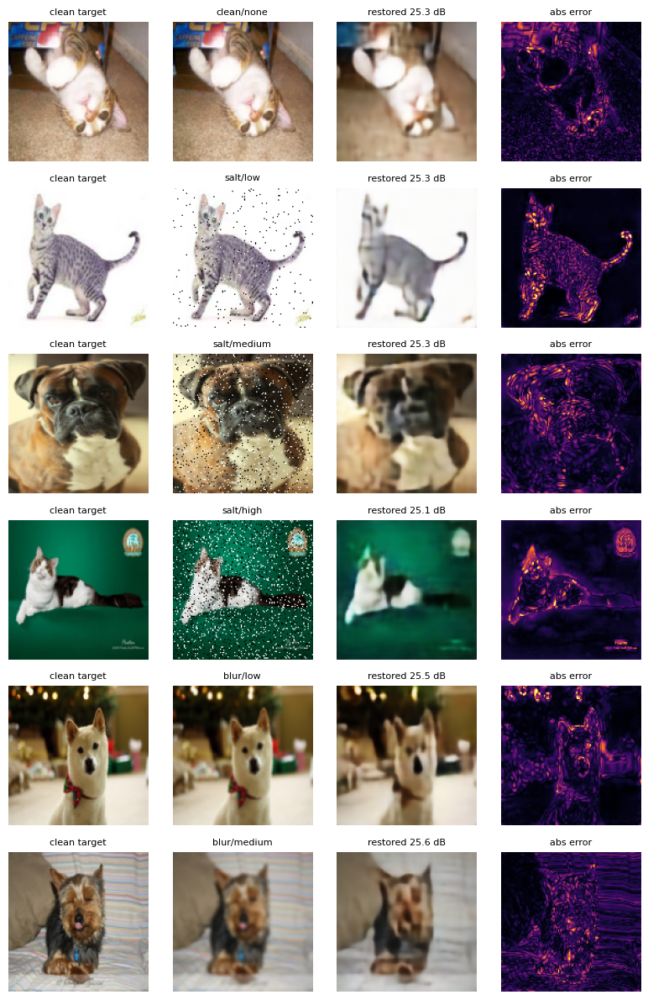

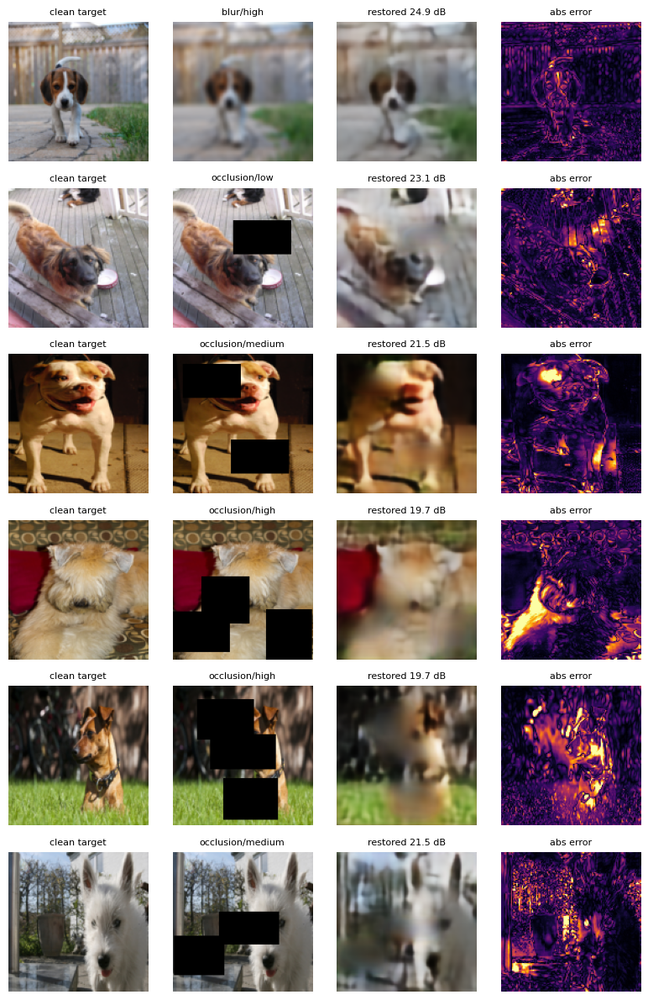

       condition severity       psnr    psnr_in      ssim   ssim_in
11439  occlusion     high  10.882427  16.636728  0.264725  0.844290
2903        salt     high  16.474468  12.838878  0.590502  0.405835
10514       blur      low  20.017511  35.316284  0.642154  0.982613
11430      clean     none  12.807674        NaN  0.356447  1.000000


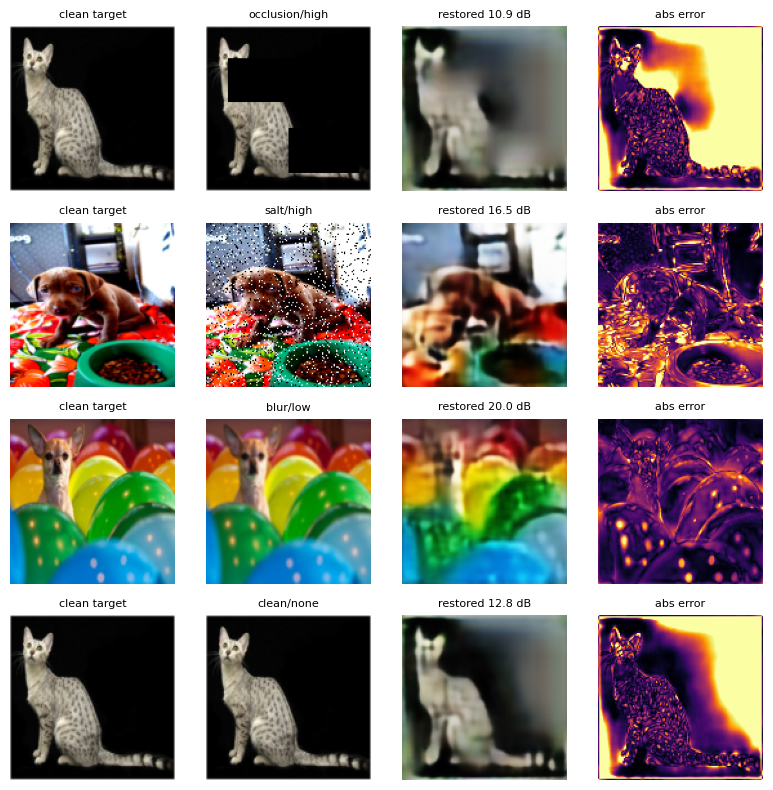

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv(f"{PROJECT_DIR}/task1_spatial_test_per_image.csv",
                 keep_default_na=False, na_values=[""])
df["gain"] = df["psnr"] - df["psnr_in"]

def pick(cond, sev, k=0):
    g = df[(df.condition == cond) & (df.severity == sev)]
    return (g["psnr"] - g["psnr"].median()).abs().sort_values().index[k]

def draw(rows, path):
    fig, axes = plt.subplots(len(rows), 4, figsize=(8, 2 * len(rows)))
    for r, j in enumerate(rows):
        x, y, _ = test_corrupted_dataset[j]
        with torch.no_grad():
            p = model(x.unsqueeze(0).to(device)).cpu()[0].clamp(0, 1)
        err = (p - y).abs().mean(0)
        e = test_manifest[j]
        panels = [(y.permute(1, 2, 0), "clean target", None),
                  (x.permute(1, 2, 0).clamp(0, 1), f"{e['condition']}/{e['severity']}", None),
                  (p.permute(1, 2, 0), f"restored {df.psnr[j]:.1f} dB", None),
                  (err, "abs error", "inferno")]
        for c, (im, t, cm) in enumerate(panels):
            axes[r, c].imshow(im, cmap=cm, vmin=0 if cm else None, vmax=0.3 if cm else None)
            axes[r, c].set_title(t, fontsize=8); axes[r, c].axis("off")
    plt.tight_layout(); plt.savefig(path, dpi=200); plt.show()

combos = [("clean", "none")] + [(c, s) for c in ["salt", "blur", "occlusion"]
                                  for s in ["low", "medium", "high"]]
rows = [pick(c, s) for c, s in combos]
rows += [pick("occlusion", "high", 1), pick("occlusion", "medium", 1)]   # 12 total
draw(rows[:6], f"{PROJECT_DIR}/task1_examples_1.png")
draw(rows[6:], f"{PROJECT_DIR}/task1_examples_2.png")

fails = [df[(df.condition == "occlusion") & (df.severity == "high")]["psnr"].idxmin(),
         df[(df.condition == "salt") & (df.severity == "high")]["psnr"].idxmin(),
         df[df.condition == "blur"]["gain"].idxmin(),
         df[df.condition == "clean"]["psnr"].idxmin()]
print(df.loc[fails, ["condition", "severity", "psnr", "psnr_in", "ssim", "ssim_in"]])
draw(fails, f"{PROJECT_DIR}/task1_failures.png")

In [ ]:
device = "cuda"
ckpt = torch.load(f"{PROJECT_DIR}/task1_spatial_best.pth", map_location=device)
model = build_model(ckpt["cfg"]).to(device); model.load_state_dict(ckpt["state_dict"]); model.eval()

In [ ]:
import onnxruntime as ort

m = build_model(ckpt["cfg"]); m.load_state_dict(ckpt["state_dict"]); m.eval()
dummy = torch.rand(1, 3, 128, 128)
onnx_path = f"{PROJECT_DIR}/task1_universal.onnx"
torch.onnx.export(m, dummy, onnx_path, input_names=["input"], output_names=["output"],
                  dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
                  opset_version=17, dynamo=False)

xs = torch.stack([test_corrupted_dataset[j][0] for j in range(0, 800, 100)])
with torch.no_grad():
    ref = m(xs).numpy()
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
out = sess.run(None, {"input": xs.numpy()})[0]
print("max abs diff:", np.abs(ref - out).max(), "| mean abs diff:", np.abs(ref - out).mean())

/tmp/ipykernel_24418/4053134009.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, dummy, onnx_path, input_names=["input"], output_names=["output"],


max abs diff: 5.662441e-07 | mean abs diff: 3.9459703e-08


In [ ]:
!pip install onnxscript

In [ ]:
!pip install -q -U protobuf onnx onnxruntime

In [ ]:
!pip install wandb optuna
wandb.login()

In [ ]:
clean = df[df.condition == "clean"].copy()
frac = []
for j in clean.index:
    _, y, _ = test_corrupted_dataset[j]
    frac.append((y.max(0).values < 0.05).float().mean().item())
clean["black_frac"] = frac
print("corr(black_frac, psnr):", clean[["black_frac", "psnr"]].corr().iloc[0, 1])
print("mean PSNR, <2% black :", clean[clean.black_frac < 0.02]["psnr"].mean())
print("mean PSNR, >20% black:", clean[clean.black_frac > 0.20]["psnr"].mean())

corr(black_frac, psnr): 0.026829889848882564
mean PSNR, <2% black : 25.342552118011554
mean PSNR, >20% black: 26.058136695254166


In [ ]:
print("cat image black_frac:", clean.loc[11430, "black_frac"])
print("images with >50% black:", (clean.black_frac > 0.50).sum())
print("mean PSNR, >50% black :", clean[clean.black_frac > 0.50]["psnr"].mean())
print("worst 5 clean PSNR:\n", clean.nsmallest(5, "psnr")[["psnr", "black_frac"]])

cat image black_frac: 0.66473388671875
images with >50% black: 10
mean PSNR, >50% black : 23.432231140136718
worst 5 clean PSNR:
             psnr  black_frac
11430  12.807674    0.664734
33910  15.287772    0.145264
2900   16.678150    0.054565
10670  16.763184    0.190430
31740  17.442549    0.145447


##TASK 2

In [ ]:
import random, torch, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader, Sampler

class LabeledTrainDataset(Dataset):
    """k = (img_idx, label) -> that corruption; k = int -> random label from `allowed`."""
    def __init__(self, base, allowed=(0,1,2,3)):
        self.base, self.allowed = base, list(allowed)
    def __len__(self): return len(self.base)
    def __getitem__(self, k):
        idx, label = k if isinstance(k, tuple) else (k, random.choice(self.allowed))
        clean, _ = self.base[idx]
        c = CORRUPTION_TYPES[label]
        if c == "clean": x = clean.clone()
        elif c == "salt": x, _ = apply_salt_and_pepper(clean)
        elif c == "blur": x, _ = apply_gaussian_blur(clean)
        else: x, _ = apply_occlusion(clean)
        return x, clean, label

class BalancedBatchSampler(Sampler):
    def __init__(self, n, batch_size):
        assert batch_size % 4 == 0
        self.n, self.bs = n, batch_size
    def __len__(self): return self.n // self.bs
    def __iter__(self):
        perm = torch.randperm(self.n).tolist()
        for b in range(len(self)):
            labels = [0, 1, 2, 3] * (self.bs // 4); random.shuffle(labels)
            yield list(zip(perm[b*self.bs:(b+1)*self.bs], labels))

class CondSubset(Dataset):
    """Manifest entries of one condition only (for specialist validation/test)."""
    def __init__(self, ds, manifest, conds):
        self.ds = ds; self.ids = [i for i, e in enumerate(manifest) if e["condition"] in conds]
    def __len__(self): return len(self.ids)
    def __getitem__(self, i): return self.ds[self.ids[i]]

cls_train_ds = LabeledTrainDataset(train_dataset)

In [ ]:
import torch.nn as nn, torch.nn.functional as F, wandb, optuna
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
device = "cuda"

class CorruptionCNN(nn.Module):
    def __init__(self, chs=(32,64,128,256), dropout=0.3):
        super().__init__()
        L, cin = [], 3
        for c in chs:
            L += [nn.Conv2d(cin, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True),
                  nn.Conv2d(c, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True), nn.MaxPool2d(2)]
            cin = c
        self.features = nn.Sequential(*L)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, 4))
    def forward(self, x): return self.head(self.features(x))   # logits

CH_CFGS = {"s": (16,32,64,128), "m": (32,64,128,256), "l": (64,128,256,512), "deep": (32,64,128,256,512)}

@torch.no_grad()
def eval_cls(model, loader):
    model.eval(); P, Y = [], []
    for x, _, y in loader:
        P.append(model(x.to(device)).argmax(1).cpu()); Y.append(y)
    P, Y = torch.cat(P).numpy(), torch.cat(Y).numpy()
    p, r, f, _ = precision_recall_fscore_support(Y, P, average="macro", zero_division=0)
    return {"val_acc": accuracy_score(Y, P), "val_prec": p, "val_rec": r, "val_f1": f}, P, Y

def train_cls(cfg, epochs, trial=None, log=True):
    model = CorruptionCNN(CH_CFGS[cfg["ch"]], cfg["dropout"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    tl = DataLoader(cls_train_ds, batch_sampler=BalancedBatchSampler(len(cls_train_ds), cfg["batch_size"]),
                    num_workers=2, persistent_workers=True)
    vl = DataLoader(val_corrupted_dataset, batch_size=64, num_workers=2)
    best, best_state = -1, None
    for ep in range(epochs):
        model.train(); run = 0
        for x, _, y in tl:
            loss = F.cross_entropy(model(x.to(device)), y.to(device))
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
        sched.step()
        m, _, _ = eval_cls(model, vl); m["train_loss"] = run/len(tl); m["epoch"] = ep
        if log: wandb.log(m)
        if m["val_f1"] > best:
            best = m["val_f1"]; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if trial:
            trial.report(m["val_f1"], ep)
            if trial.should_prune(): raise optuna.TrialPruned()
    return model, best, best_state

def objective_cls(trial):
    cfg = {"lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
           "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
           "ch": trial.suggest_categorical("ch", list(CH_CFGS)),
           "dropout": trial.suggest_float("dropout", 0.0, 0.5),
           "wd": trial.suggest_float("wd", 1e-6, 1e-2, log=True)}
    wandb.init(project="genai-ass1", group="task2-cls-optuna", name=f"t2c-trial{trial.number}", config=cfg, reinit=True)
    try:
        _, best, _ = train_cls(cfg, epochs=6, trial=trial)
        wandb.log({"best_val_f1": best}); return best
    finally: wandb.finish()

study_cls = optuna.create_study(direction="maximize", study_name="task2_cls",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    storage=f"sqlite:///{PROJECT_DIR}/task2_optuna.db", load_if_exists=True)
study_cls.optimize(objective_cls, n_trials=20)
print(study_cls.best_trial.number, study_cls.best_value, study_cls.best_params)

In [ ]:
best_cls = study_cls.best_params
wandb.init(project="genai-ass1", group="task2-final", name="t2-classifier", config={**best_cls, "epochs": 30}, reinit=True)
clf, f1, st = train_cls(best_cls, epochs=30); wandb.finish()
torch.save({"cfg": best_cls, "state_dict": st}, f"{PROJECT_DIR}/task2_classifier.pth")
print("best val macro-F1:", f1)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bb2f7f72b60>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7bb2f7f72b60>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▄▃▂▂▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇▇▇██▇███████████████████████
val_f1,▁▇▇▇██▇███████████████████████
val_prec,▁▆▆▇█▇▇█▇█████████████████████
val_rec,▁▇▇▇█▇▇█▇█████████████████████
epoch,29
train_loss,0.00648
val_acc,0.99864
val_f1,0.9986
val_prec,0.99874


best val macro-F1: 0.9985993416905946


In [ ]:
def train_ae(cfg, train_ds, val_ds, epochs, trial=None, log=True):
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    tl = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, num_workers=2,
                    drop_last=True, persistent_workers=True)
    vl = DataLoader(val_ds, batch_size=64, num_workers=2)
    best, best_state = 1e9, None
    for ep in range(epochs):
        model.train(); run = 0
        for x, y, _ in tl:
            x, y = x.to(device), y.to(device)
            loss = restoration_loss(model(x), y, cfg["alpha"])
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
        sched.step()
        m = evaluate(model, vl); m["train_loss"] = run/len(tl); m["epoch"] = ep
        if log: wandb.log(m)
        if m["val_score"] < best:
            best = m["val_score"]; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if trial:
            trial.report(m["val_score"], ep)
            if trial.should_prune(): raise optuna.TrialPruned()
    return model, best, best_state

mixed_train = LabeledTrainDataset(train_dataset, allowed=(1, 2, 3))
mixed_val = CondSubset(val_corrupted_dataset, val_manifest, {"salt", "blur", "occlusion"})

def objective_spec(trial):
    cfg = {"arch": "spatial",
           "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
           "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
           "latent_ch": trial.suggest_categorical("latent_ch", [16, 32, 64, 128]),
           "base_ch": trial.suggest_categorical("base_ch", [32, 48, 64]),
           "dropout": trial.suggest_float("dropout", 0.0, 0.3),
           "alpha": trial.suggest_float("alpha", 0.5, 0.95)}
    wandb.init(project="genai-ass1", group="task2-spec-optuna", name=f"t2s-trial{trial.number}", config=cfg, reinit=True)
    try:
        _, best, _ = train_ae(cfg, mixed_train, mixed_val, epochs=6, trial=trial)
        wandb.log({"best_val_score": best}); return best
    finally: wandb.finish()

study_spec = optuna.create_study(direction="minimize", study_name="task2_specialists",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    storage=f"sqlite:///{PROJECT_DIR}/task2_optuna.db", load_if_exists=True)
study_spec.optimize(objective_spec, n_trials=20)
print(study_spec.best_trial.number, study_spec.best_value, study_spec.best_params)

[I 2026-10-03 08:17:05,326] A new study created in RDB with name: task2_specialists


best_val_score,▁
epoch,▁▂▄▅▇█
train_loss,█▄▃▂▁▁
val_l1,▇█▆▄▁▂
val_psnr,▁▁▃▅█▇
val_score,█▆▄▃▁▁
val_ssim,▁▃▅▆██
best_val_score,0.4099
epoch,5
train_loss,0.10255
val_l1,0.05742


[I 2026-10-03 08:18:59,786] Trial 0 finished with value: 0.4098975302141166 and parameters: {'lr': 0.0003574712922600243, 'batch_size': 16, 'latent_ch': 128, 'base_ch': 48, 'dropout': 0.29097295564859826, 'alpha': 0.8745991883601898}. Best is trial 0 with value: 0.4098975302141166.


best_val_score,▁
epoch,▁▂▄▅▇█
train_loss,█▄▃▂▁▁
val_l1,█▇▆▄▂▁
val_psnr,▁▁▂▄▆█
val_score,█▇▅▃▂▁
val_ssim,▁▃▄▆▇█
best_val_score,0.44258
epoch,5
train_loss,0.10901
val_l1,0.05759


[I 2026-10-03 08:20:58,062] Trial 1 finished with value: 0.4425836923104723 and parameters: {'lr': 0.00020589728197687926, 'batch_size': 64, 'latent_ch': 128, 'base_ch': 64, 'dropout': 0.13682099526511077, 'alpha': 0.8533291826268561}. Best is trial 0 with value: 0.4098975302141166.


...

best_val_score,▁
epoch,▁▂▄▅▇█
train_loss,█▄▃▂▁▁
val_l1,█▄▂▃▂▁
val_psnr,▁▅▇▆▇█
val_score,█▄▂▂▂▁
val_ssim,▁▅▇▇▇█
best_val_score,0.36858
epoch,5
train_loss,0.18535
val_l1,0.0522


[I 2026-10-03 08:49:49,186] Trial 18 finished with value: 0.3685818706780516 and parameters: {'lr': 0.000218733120588636, 'batch_size': 16, 'latent_ch': 32, 'base_ch': 64, 'dropout': 0.09904072443985709, 'alpha': 0.5369786973117006}. Best is trial 13 with value: 0.3503892420097067.


best_val_score,▁
epoch,▁▂▄▅▇█
train_loss,█▄▃▂▁▁
val_l1,▅█▂▃▂▁
val_psnr,▃▁▆▅▇█
val_score,██▃▃▂▁
val_ssim,▁▂▆▆▇█
best_val_score,0.35731
epoch,5
train_loss,0.15259
val_l1,0.05389


[I 2026-10-03 08:51:49,058] Trial 19 finished with value: 0.35731429648284924 and parameters: {'lr': 0.0006278436797373171, 'batch_size': 16, 'latent_ch': 32, 'base_ch': 64, 'dropout': 0.024938667518826847, 'alpha': 0.6358073535306328}. Best is trial 13 with value: 0.3503892420097067.


13 0.3503892420097067 {'lr': 0.0007274920213019986, 'batch_size': 16, 'latent_ch': 32, 'base_ch': 64, 'dropout': 0.011854820618336426, 'alpha': 0.557340801610828}


In [15]:
!pip install -q optuna


In [ ]:
import optuna
# --- keep these exactly as before ---
def train_ae(cfg, train_ds, val_ds, epochs, trial=None, log=True):
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    tl = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, num_workers=2,
                    drop_last=True, persistent_workers=True)
    vl = DataLoader(val_ds, batch_size=64, num_workers=2)
    best, best_state = 1e9, None
    for ep in range(epochs):
        model.train(); run = 0
        for x, y, _ in tl:
            x, y = x.to(device), y.to(device)
            loss = restoration_loss(model(x), y, cfg["alpha"])
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
        sched.step()
        m = evaluate(model, vl); m["train_loss"] = run/len(tl); m["epoch"] = ep
        if log: wandb.log(m)
        if m["val_score"] < best:
            best = m["val_score"]; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if trial:
            trial.report(m["val_score"], ep)
            if trial.should_prune(): raise optuna.TrialPruned()
    return model, best, best_state

mixed_train = LabeledTrainDataset(train_dataset, allowed=(1, 2, 3))
mixed_val = CondSubset(val_corrupted_dataset, val_manifest, {"salt", "blur", "occlusion"})

# --- load the finished study instead of running it ---
study_spec = optuna.load_study(
    study_name="task2_specialists",
    storage=f"sqlite:///{PROJECT_DIR}/task2_optuna.db")
print(study_spec.best_trial.number, study_spec.best_value, study_spec.best_params)
print(study_spec.trials_dataframe()["state"].value_counts())

In [ ]:
class SingleCondTrain(Dataset):
    def __init__(self, base, label): self.d, self.l = LabeledTrainDataset(base), label
    def __len__(self): return len(self.d)
    def __getitem__(self, i): return self.d[(i, self.l)]

best_spec = {**study_spec.best_params, "arch": "spatial"}
SPEC_NAMES = {1: "salt", 2: "blur", 3: "occlusion"}
for lab, name in SPEC_NAMES.items():
    wandb.init(project="genai-ass1", group="task2-final", name=f"t2-spec-{name}",
               config={**best_spec, "epochs": 40, "cond": name}, reinit=True)
    tr = SingleCondTrain(train_dataset, lab)
    va = CondSubset(val_corrupted_dataset, val_manifest, {name})
    _, best, st = train_ae(best_spec, tr, va, epochs=40); wandb.finish()
    torch.save({"cfg": best_spec, "state_dict": st}, f"{PROJECT_DIR}/task2_spec_{name}.pth")
    print(name, "best val_score:", best)

{'val_acc': 0.9982829108748978, 'val_prec': 0.9972047367642535, 'val_rec': 0.9970700463341511, 'val_f1': 0.9971372898328962}
              precision    recall  f1-score   support

       clean     0.9918    0.9910    0.9914      3669
        salt     1.0000    1.0000    1.0000     11007
        blur     0.9985    0.9994    0.9990     11007
   occlusion     0.9985    0.9979    0.9982     11007

    accuracy                         0.9983     36690
   macro avg     0.9972    0.9971    0.9971     36690
weighted avg     0.9983    0.9983    0.9983     36690



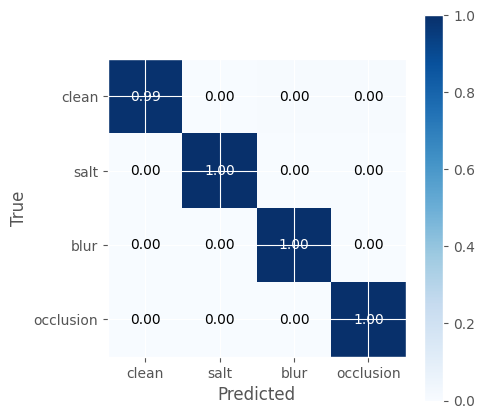

c          s     
blur       high      1.0000
           low       0.9981
           medium    1.0000
clean      none      0.9910
occlusion  high      1.0000
           low       0.9937
           medium    1.0000
salt       high      1.0000
           low       1.0000
           medium    1.0000
Name: ok, dtype: float64


In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
ck = torch.load(f"{PROJECT_DIR}/task2_classifier.pth", map_location=device)
clf = CorruptionCNN(CH_CFGS[ck["cfg"]["ch"]], ck["cfg"]["dropout"]).to(device)
clf.load_state_dict(ck["state_dict"]); clf.eval()

tl = DataLoader(test_corrupted_dataset, batch_size=128, num_workers=2)
m, P, Y = eval_cls(clf, tl)
print(m); print(classification_report(Y, P, target_names=CORRUPTION_TYPES, digits=4))
cm = confusion_matrix(Y, P, normalize="true")
fig, ax = plt.subplots(figsize=(5, 4.5)); im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(CORRUPTION_TYPES); ax.set_yticks(range(4)); ax.set_yticklabels(CORRUPTION_TYPES)
for i in range(4):
    for j in range(4): ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", color="white" if cm[i,j] > .5 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); plt.colorbar(im); plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/task2_confusion.png", dpi=200); plt.show()

# accuracy by condition x severity (expect clean/blur-low confusion)
sev = np.array([e["severity"] for e in test_manifest]); cnd = np.array([e["condition"] for e in test_manifest])
print(pd.DataFrame({"c": cnd, "s": sev, "ok": P == Y}).groupby(["c", "s"]).ok.mean().round(4))

In [11]:
def ssim_per_image(x, y, C1=0.01**2, C2=0.03**2):
    w = _gauss_win(device=x.device)
    f = lambda t: F.conv2d(t, w, padding=5, groups=3)
    mx, my = f(x), f(y)
    sxx, syy, sxy = f(x*x) - mx**2, f(y*y) - my**2, f(x*y) - mx*my
    s = ((2*mx*my + C1) * (2*sxy + C2)) / ((mx**2 + my**2 + C1) * (sxx + syy + C2))
    return s.mean(dim=(1, 2, 3))

def per_image(p, y):
    l1 = (p - y).abs().mean(dim=(1, 2, 3))
    mse = ((p - y) ** 2).mean(dim=(1, 2, 3))
    ps = (10 * torch.log10(1.0 / mse.clamp_min(1e-10))).clamp(max=50)
    return l1, ps, ssim_per_image(p, y)

In [ ]:
specs = {}
for lab, name in SPEC_NAMES.items():
    ck = torch.load(f"{PROJECT_DIR}/task2_spec_{name}.pth", map_location=device)
    specs[lab] = build_model(ck["cfg"]).to(device); specs[lab].load_state_dict(ck["state_dict"]); specs[lab].eval()

@torch.no_grad()
def route(x, r):
    out = x.clone()                                   # label 0 -> identity bypass
    for lab, s in specs.items():
        mask = r == lab
        if mask.any(): out[mask] = s(x[mask])
    return out

rows, i = [], 0
with torch.no_grad():
    for x, y, lab in tl:
        x, y, lab = x.to(device), y.to(device), lab.to(device)
        prob = F.softmax(clf(x), 1); pred = prob.argmax(1)
        o_or, o_pr = route(x, lab), route(x, pred)
        a, b, c = per_image(x, y), per_image(o_or, y), per_image(o_pr, y)
        for k in range(x.size(0)):
            e = test_manifest[i]
            rows.append(dict(i=i, condition=e["condition"], severity=e["severity"], true=lab[k].item(), pred=pred[k].item(),
                l1_in=a[0][k].item(), psnr_in=a[1][k].item(), ssim_in=a[2][k].item(),
                l1_or=b[0][k].item(), psnr_or=b[1][k].item(), ssim_or=b[2][k].item(),
                l1_pr=c[0][k].item(), psnr_pr=c[1][k].item(), ssim_pr=c[2][k].item()))
            i += 1
res = pd.DataFrame(rows); res.to_csv(f"{PROJECT_DIR}/task2_test_per_image.csv", index=False)
co = {"clean": 0, "salt": 1, "blur": 2, "occlusion": 3}; so = {"none": 0, "low": 1, "medium": 2, "high": 3}
tbl = res.groupby(["condition", "severity"]).mean(numeric_only=True).drop(columns=["i", "true", "pred"]).round(4).reset_index()
tbl = tbl.sort_values(["condition", "severity"], key=lambda s: s.map(co if s.name == "condition" else so)).set_index(["condition", "severity"])
print(tbl); tbl.to_csv(f"{PROJECT_DIR}/task2_test_results.csv")
print("overall (corrupted only):",
      res[res.condition != "clean"][["psnr_in","psnr_or","psnr_pr","ssim_in","ssim_or","ssim_pr"]].mean().round(4))

                     l1_in  psnr_in  ssim_in   l1_or  psnr_or  ssim_or  \
condition severity                                                       
clean     none      0.0000  50.0000   1.0000  0.0000  50.0000   1.0000   
salt      low       0.0148  20.2154   0.6168  0.0306  27.3042   0.8460   
          medium    0.0384  16.0665   0.3663  0.0309  27.2298   0.8430   
          high      0.0696  13.4827   0.2372  0.0315  27.0646   0.8364   
blur      low       0.0129  34.0744   0.9613  0.0316  27.0561   0.8426   
          medium    0.0260  28.0647   0.8548  0.0308  27.2920   0.8412   
          high      0.0362  25.3187   0.7545  0.0337  26.4017   0.8005   
occlusion low       0.0440  16.7655   0.8792  0.0391  24.2087   0.7925   
          medium    0.0879  13.3798   0.7639  0.0456  22.5534   0.7563   
          high      0.1529  10.8394   0.5998  0.0568  20.6016   0.6991   

                     l1_pr  psnr_pr  ssim_pr  
condition severity                            
clean     none   

63 misrouted of 36690
true  pred
0     2       16
      3       17
2     0        7
3     0       23
dtype: int64
       true  pred  condition severity    psnr_or    psnr_pr       drop
11430     0     3      clean     none  50.000000  13.412303  36.587697
11560     0     2      clean     none  50.000000  24.884729  25.115271
23597     3     0  occlusion      low  25.872406  16.905993   8.966413
7384      2     0       blur      low  29.964859  33.435066  -3.470207
           count   mean
true pred              
0    2        16  19.70
     3        17  26.83
2    0         7  -5.70
3    0        23  -2.80


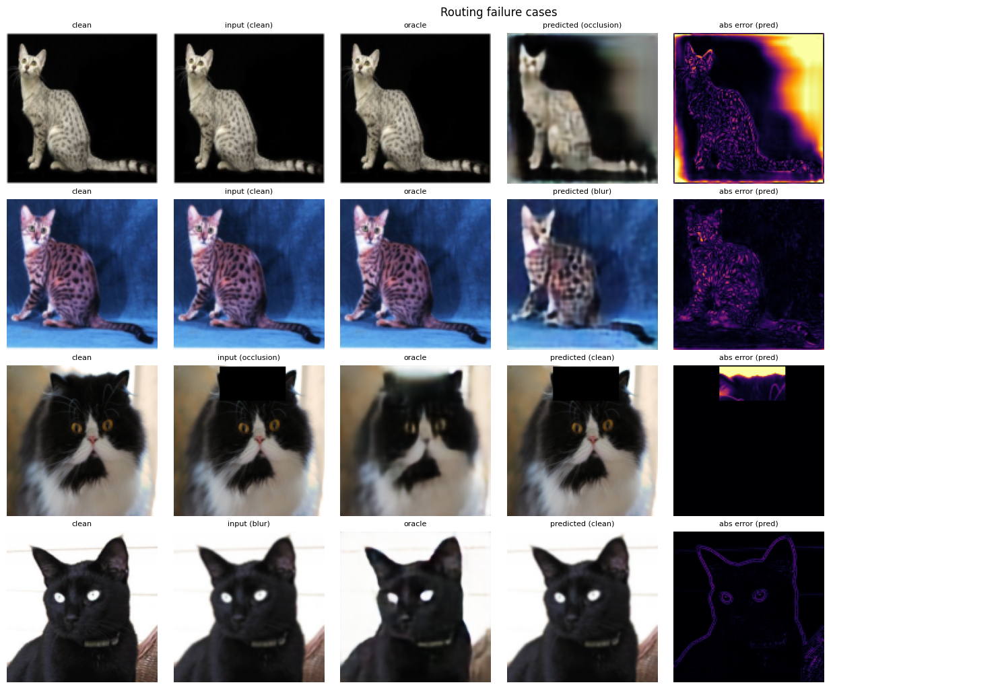

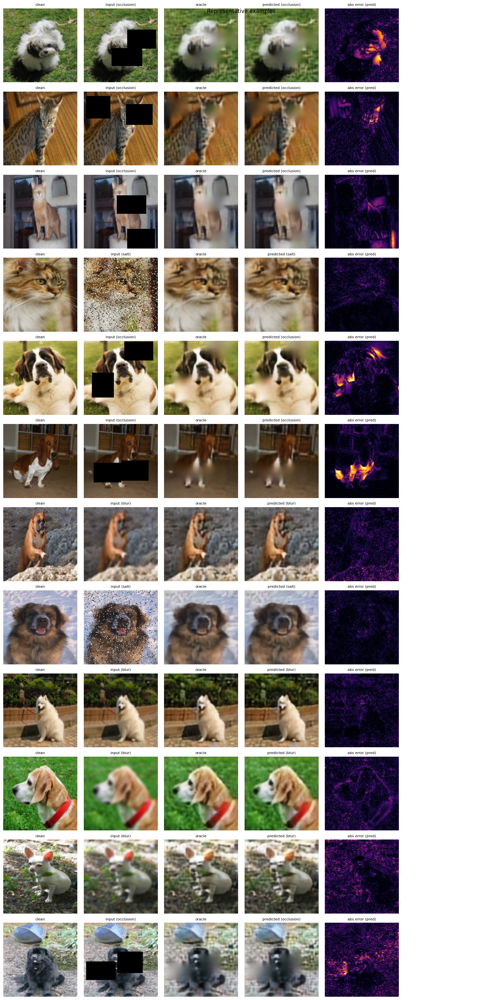

In [ ]:
fail = res[res.true != res.pred].copy()
fail["drop"] = fail.psnr_or - fail.psnr_pr
print(len(fail), "misrouted of", len(res)); print(fail.groupby(["true", "pred"]).size())
worst = (fail.sort_values("drop", ascending=False)
             .groupby(["true", "pred"]).head(1).head(4))
print(worst[["true", "pred", "condition", "severity", "psnr_or", "psnr_pr", "drop"]])
print(fail.groupby(["true", "pred"])["drop"].agg(["count", "mean"]).round(2))

def grid(idxs, title, fname):
    fig, ax = plt.subplots(len(idxs), 6, figsize=(15, 2.6*len(idxs)))
    for r_, j in enumerate(idxs):
        x, y, lab = test_corrupted_dataset[j]; xb = x[None].to(device)
        with torch.no_grad():
            pr = F.softmax(clf(xb), 1).argmax(1)
            lt = torch.tensor([lab], device=device)
            o_or, o_pr = route(xb, lt), route(xb, pr)
        imgs = [y, x, o_or[0].cpu(), o_pr[0].cpu(), (o_pr[0].cpu() - y).abs().mean(0)]
        names = ["clean", f"input ({CORRUPTION_TYPES[lab]})", "oracle", f"predicted ({CORRUPTION_TYPES[pr.item()]})", "abs error (pred)"]
        for c_ in range(5):
            im = imgs[c_]
            ax[r_, c_].imshow(im.permute(1, 2, 0).clamp(0, 1) if im.ndim == 3 else im, cmap=None if im.ndim == 3 else "inferno", vmin=None if im.ndim == 3 else 0, vmax=None if im.ndim == 3 else 0.5)
            ax[r_, c_].set_title(names[c_], fontsize=8); ax[r_, c_].axis("off")
        ax[r_, 5].axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.savefig(f"{PROJECT_DIR}/{fname}", dpi=200); plt.show()

grid(worst.i.tolist(), "Routing failure cases", "task2_failures.png")
rng_ = np.random.RandomState(0)
grid(rng_.choice(res[res.true == res.pred].i.values, 12, replace=False).tolist(), "Representative examples", "task2_examples.png")

In [12]:
import optuna, pandas as pd, matplotlib.pyplot as plt
from optuna.visualization import matplotlib as optv

study_cls = optuna.load_study(study_name="task2_cls",
    storage=f"sqlite:///{PROJECT_DIR}/task2_optuna.db")
study_spec = optuna.load_study(study_name="task2_specialists",
    storage=f"sqlite:///{PROJECT_DIR}/task2_optuna.db")

for name, st in [("cls", study_cls), ("spec", study_spec)]:
    d = st.trials_dataframe()
    d.to_csv(f"{PROJECT_DIR}/task2_{name}_optuna_trials.csv", index=False)
    print(name, "| best trial", st.best_trial.number, "| value", round(st.best_value, 4))
    print(st.best_params, d["state"].value_counts().to_dict())
    for pn, fn in [("history", optv.plot_optimization_history),
                   ("importance", optv.plot_param_importances),
                   ("parallel", optv.plot_parallel_coordinate)]:
        try:
            fn(st); plt.tight_layout()
            plt.savefig(f"{PROJECT_DIR}/task2_{name}_optuna_{pn}.png", dpi=200); plt.show()
        except Exception as e:
            print("skipped", pn, "-", e)

ModuleNotFoundError: No module named 'optuna'

In [13]:
import torch, torch.nn as nn, torch.nn.functional as F
device = "cuda"

class CorruptionCNN(nn.Module):
    def __init__(self, chs=(32,64,128,256), dropout=0.3):
        super().__init__()
        L, cin = [], 3
        for c in chs:
            L += [nn.Conv2d(cin, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True),
                  nn.Conv2d(c, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True), nn.MaxPool2d(2)]
            cin = c
        self.features = nn.Sequential(*L)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, 4))
    def forward(self, x): return self.head(self.features(x))

CH_CFGS = {"s": (16,32,64,128), "m": (32,64,128,256), "l": (64,128,256,512), "deep": (32,64,128,256,512)}
SPEC_NAMES = {1: "salt", 2: "blur", 3: "occlusion"}

ck = torch.load(f"{PROJECT_DIR}/task2_classifier.pth", map_location=device)
clf = CorruptionCNN(CH_CFGS[ck["cfg"]["ch"]], ck["cfg"]["dropout"]).to(device)
clf.load_state_dict(ck["state_dict"]); clf.eval()

specs = {}
for lab, name in SPEC_NAMES.items():
    c_ = torch.load(f"{PROJECT_DIR}/task2_spec_{name}.pth", map_location=device)
    specs[lab] = build_model(c_["cfg"]).to(device)
    specs[lab].load_state_dict(c_["state_dict"]); specs[lab].eval()

@torch.no_grad()
def route(x, r):
    out = x.clone()                      # label 0 -> identity bypass
    for lab, s in specs.items():
        mask = r == lab
        if mask.any(): out[mask] = s(x[mask])
    return out

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [19]:
import copy, numpy as np, onnxruntime as ort, os

class ClsProb(nn.Module):               # classifier exported with softmax -> 4 probabilities
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return F.softmax(self.m(x), 1)

def export(model, path, out_name):
    m = copy.deepcopy(model).cpu().eval()
    torch.onnx.export(m, torch.rand(1, 3, 128, 128), path,
                      input_names=["input"], output_names=[out_name],
                      dynamic_axes={"input": {0: "batch"}, out_name: {0: "batch"}},
                      opset_version=17, dynamo=False)
    return ort.InferenceSession(path, providers=["CPUExecutionProvider"])

xs = torch.stack([test_corrupted_dataset[j][0] for j in range(0, 3700, 37)])   # ~100 mixed test inputs
xn = xs.numpy()

# classifier
sess_c = export(ClsProb(clf), f"{PROJECT_DIR}/task2_classifier.onnx", "probs")
with torch.no_grad():
    ref_p = F.softmax(clf(xs.to(device)), 1).cpu().numpy()
out_p = sess_c.run(None, {"input": xn})[0]
print("classifier max abs diff:", np.abs(ref_p - out_p).max(),
      "| argmax agreement:", (ref_p.argmax(1) == out_p.argmax(1)).mean())

# specialists
sess_s = {}
for lab, name in SPEC_NAMES.items():
    sess_s[lab] = export(specs[lab], f"{PROJECT_DIR}/task2_specialist_{name}.onnx", "output")
    with torch.no_grad():
        ref = specs[lab](xs.to(device)).cpu().numpy()
    out = sess_s[lab].run(None, {"input": xn})[0]
    print(f"{name} max abs diff:", np.abs(ref - out).max())

# full hard-routed pipeline, ONNX vs PyTorch (predicted routing)
def route_onnx(x_np):
    pr = sess_c.run(None, {"input": x_np})[0].argmax(1)
    out = x_np.copy()                                  # label 0 = identity bypass
    for lab, s in sess_s.items():
        m = pr == lab
        if m.any(): out[m] = s.run(None, {"input": x_np[m]})[0]
    return out

with torch.no_grad():
    xd = xs.to(device); ref_route = route(xd, clf(xd).argmax(1)).cpu().numpy()
print("end-to-end routed max abs diff:", np.abs(ref_route - route_onnx(xn)).max())

for f in sorted(os.listdir(PROJECT_DIR)):
    if f.endswith(".onnx"): print(f, round(os.path.getsize(f"{PROJECT_DIR}/{f}") / 1e6, 1), "MB")

/tmp/ipykernel_21676/244350465.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, torch.rand(1, 3, 128, 128), path,


classifier max abs diff: 3.427267e-07 | argmax agreement: 1.0
salt max abs diff: 7.0035458e-06
blur max abs diff: 5.3048134e-06
occlusion max abs diff: 6.735325e-06
end-to-end routed max abs diff: 7.0035458e-06
task1_universal.onnx 17.4 MB
task2_classifier.onnx 18.9 MB
task2_specialist_blur.onnx 17.5 MB
task2_specialist_occlusion.onnx 17.5 MB
task2_specialist_salt.onnx 17.5 MB


In [15]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 5.6 MB/s eta 0:00:00


##TASK 3


In [16]:

import copy, wandb, optuna, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader

BRANCHES = ["identity", "salt", "blur", "occlusion"]
gate_cfg = ck["cfg"]
spec_cfg = torch.load(f"{PROJECT_DIR}/task2_spec_salt.pth", map_location="cpu")["cfg"]

class SoftMoE(nn.Module):
    def __init__(self, gate, experts, tau=1.0):
        super().__init__()
        self.gate, self.experts, self.tau = gate, nn.ModuleList(experts), tau
    def forward(self, x, full=False):
        w = F.softmax(self.gate(x) / self.tau, 1)               # [B,4]: identity, salt, blur, occlusion
        outs = [x] + [e(x) for e in self.experts]
        y = sum(w[:, k].view(-1, 1, 1, 1) * outs[k] for k in range(4))
        return (y, w) if full else y

def make_moe(tau):   # gate <- Task 2 classifier, experts <- Task 2 specialists
    return SoftMoE(copy.deepcopy(clf), [copy.deepcopy(specs[l]) for l in (1, 2, 3)], tau).to(device)

def balance_loss(w): return ((w.mean(0) - 0.25) ** 2).sum()

def moe_loss(y, target, w, label, hp):
    l1, ss = F.l1_loss(y, target), 1 - ssim(y, target)
    ce = F.nll_loss(torch.log(w.clamp_min(1e-8)), label)        # CE on the tempered gate output
    bal = balance_loss(w)
    return hp["w_l1"]*l1 + (1 - hp["w_l1"])*ss + hp["w_ce"]*ce + hp["w_bal"]*bal

@torch.no_grad()
def eval_moe(model, loader):
    model.eval(); l1 = ss = 0; n = 0; W, Yl = [], []
    for x, y, lab in loader:
        x, y = x.to(device), y.to(device)
        p, w = model(x, True); b = x.size(0)
        l1 += F.l1_loss(p, y).item()*b; ss += ssim(p, y).item()*b; n += b
        W.append(w.cpu()); Yl.append(lab)
    W, Yl = torch.cat(W), torch.cat(Yl); avg = W.mean(0)
    return {"val_l1": l1/n, "val_ssim": ss/n, "val_score": l1/n + 1 - ss/n,
            "w_max": avg.max().item(), "w_min": avg.min().item(),
            "route_acc": (W.argmax(1) == Yl).float().mean().item()}

def train_moe(hp, warm_epochs, joint_epochs, trial=None, log=True):
    model = make_moe(hp["tau"])
    tl = DataLoader(cls_train_ds, batch_sampler=BalancedBatchSampler(len(cls_train_ds), hp["batch_size"]),
                    num_workers=2, persistent_workers=True)
    vl = DataLoader(val_corrupted_dataset, batch_size=64, num_workers=2)
    best, best_state, step = 1e9, None, 0

    def run_epoch(opt, train_experts):
        model.train()
        if not train_experts: model.experts.eval()               # frozen experts keep BN statistics
        tot = 0
        for x, y, lab in tl:
            x, y, lab = x.to(device), y.to(device), lab.to(device)
            p, w = model(x, True)
            loss = moe_loss(p, y, w, lab, hp)
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
        return tot / len(tl)

    # stage 1: warm-up, experts frozen, gate only
    for q in model.experts.parameters(): q.requires_grad_(False)
    opt = torch.optim.AdamW(model.gate.parameters(), lr=hp["warm_lr"])
    for _ in range(warm_epochs):
        tr = run_epoch(opt, False)
        m = eval_moe(model, vl); m.update(stage=0, train_loss=tr, epoch=step)
        if log: wandb.log(m)
        step += 1
    # stage 2: joint fine-tuning, smaller lr
    for q in model.experts.parameters(): q.requires_grad_(True)
    opt = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, max(joint_epochs, 1))
    for _ in range(joint_epochs):
        tr = run_epoch(opt, True); sched.step()
        m = eval_moe(model, vl); m.update(stage=1, train_loss=tr, epoch=step)
        if log: wandb.log(m)
        if m["val_score"] < best:
            best = m["val_score"]; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if trial:
            trial.report(m["val_score"], step)
            if m["w_max"] > 0.7: raise optuna.TrialPruned()      # routing collapse: one branch takes everything
            if trial.should_prune(): raise optuna.TrialPruned()
        step += 1
    del tl
    return model, best, best_state

NameError: name 'ck' is not defined

In [ ]:
hp0 = {"lr": 1e-4, "tau": 1.0, "w_ce": 0.1, "w_bal": 0.01, "w_l1": 0.8, "batch_size": 32, "warm_lr": 1e-4}
_, b0, _ = train_moe(hp0, 1, 1, log=False); print("smoke test val_score:", b0)

def objective_moe(trial):
    hp = {"lr": trial.suggest_float("lr", 1e-5, 3e-4, log=True),
          "tau": trial.suggest_float("tau", 0.5, 3.0),
          "w_ce": trial.suggest_float("w_ce", 0.01, 1.0, log=True),
          "w_bal": trial.suggest_float("w_bal", 1e-3, 1.0, log=True),
          "w_l1": trial.suggest_float("w_l1", 0.5, 0.95),
          "batch_size": 32, "warm_lr": 1e-4}
    wandb.init(project="genai-ass1", group="task3-optuna", name=f"t3-trial{trial.number}", config=hp, reinit=True)
    try:
        _, best, _ = train_moe(hp, warm_epochs=1, joint_epochs=3, trial=trial)
        wandb.log({"best_val_score": best}); return best
    finally: wandb.finish()

study_moe = optuna.create_study(direction="minimize", study_name="task3_moe",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=1),
    storage=f"sqlite:///{PROJECT_DIR}/task3_optuna.db", load_if_exists=True)
study_moe.optimize(objective_moe, n_trials=12)
print(study_moe.best_trial.number, study_moe.best_value, study_moe.best_params)

smoke test val_score: 0.18550472382618033


[I 2026-10-04 07:56:57,895] A new study created in RDB with name: task3_moe
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [ ]:
hp = {**study_moe.best_params, "batch_size": 32, "warm_lr": 1e-4}
wandb.init(project="genai-ass1", group="task3-final", name="t3-soft-moe",
           config={**hp, "warm_epochs": 3, "joint_epochs": 20}, reinit=True)
moe, best_v, best_st = train_moe(hp, warm_epochs=3, joint_epochs=20); wandb.finish()
torch.save({"hp": hp, "state_dict": best_st, "gate_cfg": gate_cfg, "spec_cfg": spec_cfg},
           f"{PROJECT_DIR}/task3_soft_moe.pth")
print("best val_score:", best_v)

In [ ]:
moe.load_state_dict(best_st); moe.eval()
tl = DataLoader(test_corrupted_dataset, batch_size=128, num_workers=2)
WC = [f"w_{b}" for b in BRANCHES]
rows, i = [], 0
with torch.no_grad():
    for x, y, lab in tl:
        x, y = x.to(device), y.to(device)
        p, w = moe(x, True); l1, ps, ss = per_image(p, y)
        for k in range(x.size(0)):
            e = test_manifest[i]
            rows.append(dict(i=i, condition=e["condition"], severity=e["severity"], true=lab[k].item(),
                             l1_soft=l1[k].item(), psnr_soft=ps[k].item(), ssim_soft=ss[k].item(),
                             **{c: w[k, j].item() for j, c in enumerate(WC)}))
            i += 1
sm = pd.DataFrame(rows); sm.to_csv(f"{PROJECT_DIR}/task3_test_per_image.csv", index=False)

co = {"clean": 0, "salt": 1, "blur": 2, "occlusion": 3}; so = {"none": 0, "low": 1, "medium": 2, "high": 3}
def order(t):
    t = t.reset_index(); t["c"] = t.condition.map(co); t["s"] = t.severity.map(so)
    return t.sort_values(["c", "s"]).drop(columns=["c", "s"]).set_index(["condition", "severity"])

# soft vs hard (Task 2) restoration quality
t2 = pd.read_csv(f"{PROJECT_DIR}/task2_test_per_image.csv")
cmp = sm.merge(t2[["i", "psnr_in", "psnr_or", "psnr_pr", "ssim_pr"]], on="i")
tab = order(cmp.groupby(["condition", "severity"])[["psnr_in", "psnr_pr", "psnr_soft", "ssim_pr", "ssim_soft"]].mean()).round(3)
print(tab); tab.to_csv(f"{PROJECT_DIR}/task3_test_results.csv")
print("overall corrupted-only:\n", cmp[cmp.condition != "clean"][["psnr_in", "psnr_pr", "psnr_soft", "ssim_pr", "ssim_soft"]].mean().round(4))

# average gate weights per condition x severity + heatmap
wt = order(sm.groupby(["condition", "severity"])[WC].mean()).round(3)
print(wt); wt.to_csv(f"{PROJECT_DIR}/task3_gate_weights.csv")
fig, ax = plt.subplots(figsize=(6.5, 5)); im = ax.imshow(wt.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(BRANCHES); ax.set_yticks(range(len(wt)))
ax.set_yticklabels([f"{c}/{s}" for c, s in wt.index])
for a in range(wt.shape[0]):
    for b in range(4): ax.text(b, a, f"{wt.values[a, b]:.2f}", ha="center", va="center", color="white" if wt.values[a, b] < .6 else "black", fontsize=8)
plt.colorbar(im); plt.title("Mean gate weight per condition/severity"); plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/task3_routing_heatmap.png", dpi=200); plt.show()

# collapse / dead expert / unrelated dominance
top = pd.Series(sm[WC].values.argmax(1)).map(dict(enumerate(BRANCHES))).values
print("routing accuracy (argmax = true class):", (sm[WC].values.argmax(1) == sm.true.values).mean().round(4))
print("mean weight per branch (all test):\n", sm[WC].mean().round(4))
print("top-branch share by true condition:\n", pd.crosstab(sm.condition, top, normalize="index").round(3))

# examples: one expert dominates vs mixed weights
sm["wmax"] = sm[WC].max(axis=1)
dom = sm.groupby("condition").wmax.idxmax().tolist()
mix = sm.wmax.nsmallest(4).index.tolist()
print(sm.loc[mix, ["condition", "severity"] + WC].round(3))
def show(idxs, title, fname):
    fig, ax = plt.subplots(len(idxs), 5, figsize=(13, 2.4*len(idxs)))
    for r_, j in enumerate(idxs):
        x, y, _ = test_corrupted_dataset[j]
        with torch.no_grad(): p, w = moe(x[None].to(device), True)
        p, w = p[0].cpu(), w[0].cpu().numpy()
        ims = [y, x, p, (p - y).abs().mean(0)]
        names = ["clean", f"input ({sm.condition[j]}/{sm.severity[j]})", f"restored {sm.psnr_soft[j]:.1f} dB", "abs error"]
        for c_ in range(4):
            ax[r_, c_].imshow(ims[c_].permute(1, 2, 0).clamp(0, 1) if c_ < 3 else ims[c_], cmap=None if c_ < 3 else "inferno",
                              vmin=None if c_ < 3 else 0, vmax=None if c_ < 3 else 0.3)
            ax[r_, c_].set_title(names[c_], fontsize=8); ax[r_, c_].axis("off")
        ax[r_, 4].bar(BRANCHES, w); ax[r_, 4].set_ylim(0, 1); ax[r_, 4].tick_params(labelsize=6)
    plt.suptitle(title); plt.tight_layout(); plt.savefig(f"{PROJECT_DIR}/{fname}", dpi=200); plt.show()
show(dom, "One expert dominates", "task3_examples_dominant.png")
show(mix, "Mixed routing weights", "task3_examples_mixed.png")

# Optuna artifacts
from optuna.visualization import matplotlib as optv
study_moe.trials_dataframe().to_csv(f"{PROJECT_DIR}/task3_optuna_trials.csv", index=False)
print(study_moe.trials_dataframe()["state"].value_counts().to_dict())
for pn, fn in [("history", optv.plot_optimization_history), ("importance", optv.plot_param_importances),
               ("parallel", optv.plot_parallel_coordinate)]:
    try: fn(study_moe); plt.tight_layout(); plt.savefig(f"{PROJECT_DIR}/task3_optuna_{pn}.png", dpi=200); plt.show()
    except Exception as e: print("skipped", pn, e)

In [1]:
import onnxruntime as ort, os

class MoEExport(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x):
        y, w = self.m(x, True); return y, w

onnx_path = f"{PROJECT_DIR}/task3_soft_moe.onnx"
m_ = copy.deepcopy(moe).cpu().eval()
torch.onnx.export(MoEExport(m_), torch.rand(1, 3, 128, 128), onnx_path,
                  input_names=["input"], output_names=["restored", "weights"],
                  dynamic_axes={"input": {0: "batch"}, "restored": {0: "batch"}, "weights": {0: "batch"}},
                  opset_version=17, dynamo=False)

xs = torch.stack([test_corrupted_dataset[j][0] for j in range(0, 3700, 37)])
with torch.no_grad(): ref_y, ref_w = moe(xs.to(device), True)
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
out_y, out_w = sess.run(None, {"input": xs.numpy()})
print("restored max abs diff:", np.abs(ref_y.cpu().numpy() - out_y).max())
print("weights  max abs diff:", np.abs(ref_w.cpu().numpy() - out_w).max())
print(round(os.path.getsize(onnx_path) / 1e6, 1), "MB")

ModuleNotFoundError: No module named 'onnxruntime'

In [25]:
import json
print("TAU baked into ONNX:", moe.tau)
json.dump({"tau": float(moe.tau)}, open(f"{PROJECT_DIR}/moe_tau.json", "w"))

TAU baked into ONNX: 1.2615344229334267


In [17]:
import pandas as pd
sm = pd.read_csv(f"{PROJECT_DIR}/task3_test_per_image.csv")
t2 = pd.read_csv(f"{PROJECT_DIR}/task2_test_per_image.csv")
WC = ["w_identity", "w_salt", "w_blur", "w_occlusion"]

cmp = sm.merge(t2[["i", "psnr_in", "psnr_pr", "ssim_pr"]], on="i")
print(pd.read_csv(f"{PROJECT_DIR}/task3_test_results.csv"))
print("overall corrupted-only:\n", cmp[cmp.condition != "clean"][["psnr_in", "psnr_pr", "psnr_soft", "ssim_pr", "ssim_soft"]].mean().round(4))
print(pd.read_csv(f"{PROJECT_DIR}/task3_gate_weights.csv"))
print("routing accuracy:", (sm[WC].values.argmax(1) == sm.true.values).mean().round(4))
print("mean weight per branch:\n", sm[WC].mean().round(4))
top = pd.Series(sm[WC].values.argmax(1)).map(dict(enumerate(["identity", "salt", "blur", "occlusion"]))).values
print(pd.crosstab(sm.condition, top, normalize="index").round(3))
tr = pd.read_csv(f"{PROJECT_DIR}/task3_optuna_trials.csv")
print(tr["state"].value_counts().to_dict())
print(tr.loc[tr.value.idxmin()])

   condition severity  psnr_in  psnr_pr  psnr_soft  ssim_pr  ssim_soft
0      clean     none   50.000   49.790     49.764    0.998      0.999
1       salt      low   20.215   27.304     27.958    0.846      0.862
2       salt   medium   16.066   27.230     27.551    0.843      0.849
3       salt     high   13.483   27.065     27.246    0.836      0.838
4       blur      low   34.074   27.067     29.994    0.843      0.913
5       blur   medium   28.065   27.292     27.576    0.841      0.847
6       blur     high   25.319   26.402     26.501    0.800      0.800
7  occlusion      low   16.765   24.226     24.145    0.793      0.870
8  occlusion   medium   13.380   22.553     22.675    0.756      0.796
9  occlusion     high   10.839   20.602     20.535    0.699      0.718
overall corrupted-only:
 psnr_in      19.8008
psnr_pr      25.5267
psnr_soft    26.0200
ssim_pr       0.8065
ssim_soft     0.8325
dtype: float64
   condition severity  w_identity  w_salt  w_blur  w_occlusion
0      clea

In [24]:
import copy, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, onnxruntime as ort

class CorruptionCNN(nn.Module):
    def __init__(self, chs=(32,64,128,256), dropout=0.3):
        super().__init__()
        L, cin = [], 3
        for c in chs:
            L += [nn.Conv2d(cin, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True),
                  nn.Conv2d(c, c, 3, 1, 1), nn.BatchNorm2d(c), nn.ReLU(True), nn.MaxPool2d(2)]
            cin = c
        self.features = nn.Sequential(*L)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, 4))
    def forward(self, x): return self.head(self.features(x))

CH_CFGS = {"s": (16,32,64,128), "m": (32,64,128,256), "l": (64,128,256,512), "deep": (32,64,128,256,512)}

class SoftMoE(nn.Module):
    def __init__(self, gate, experts, tau=1.0):
        super().__init__()
        self.gate, self.experts, self.tau = gate, nn.ModuleList(experts), tau
    def forward(self, x, full=False):
        w = F.softmax(self.gate(x) / self.tau, 1)
        outs = [x] + [e(x) for e in self.experts]
        y = sum(w[:, k].view(-1, 1, 1, 1) * outs[k] for k in range(4))
        return (y, w) if full else y

ck3 = torch.load(f"{PROJECT_DIR}/task3_soft_moe.pth", map_location="cpu")
gate = CorruptionCNN(CH_CFGS[ck3["gate_cfg"]["ch"]], ck3["gate_cfg"]["dropout"])
moe = SoftMoE(gate, [build_model(ck3["spec_cfg"]) for _ in range(3)], ck3["hp"]["tau"])
moe.load_state_dict(ck3["state_dict"]); moe.eval()

xs = torch.stack([test_corrupted_dataset[j][0] for j in range(0, 3700, 37)])
with torch.no_grad(): ref_y, ref_w = moe(xs, True)
sess = ort.InferenceSession(f"{PROJECT_DIR}/task3_soft_moe.onnx", providers=["CPUExecutionProvider"])
out_y, out_w = sess.run(None, {"input": xs.numpy()})
print("restored max abs diff:", np.abs(ref_y.numpy() - out_y).max())
print("weights  max abs diff:", np.abs(ref_w.numpy() - out_w).max())

restored max abs diff: 3.0100346e-06
weights  max abs diff: 3.874302e-07


In [19]:
!pip install -q wandb optuna onnx onnxruntime onnxscript "protobuf>=6.31.1,<7"!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 21.3 MB/s eta 0:00:00


In [20]:
!pip install -q wandb optuna onnx onnxruntime onnxscript "protobuf>=6.31.1,<7"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
